In [57]:
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
#excel file 
file_path = r"C:\Users\morga\OneDrive\Documents\GitHub\Project-Strategic-Analysis\CA1---Project-Strategic-Analysis\sales-data.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

In [61]:
# to avoid errors
df.columns = df.columns.str.strip()

# datetime format for proper analysis
df['Date'] = pd.to_datetime(df['Date'])

# filter data to start from Tuesday (11/02)
df_main = df[df['Date'] >= '2025-02-11']

## SALES TREND OVER TIME   


* Shows how daily sales change over time;
* Helps identify peak sales days and slow periods;
* Useful for predicting demand.

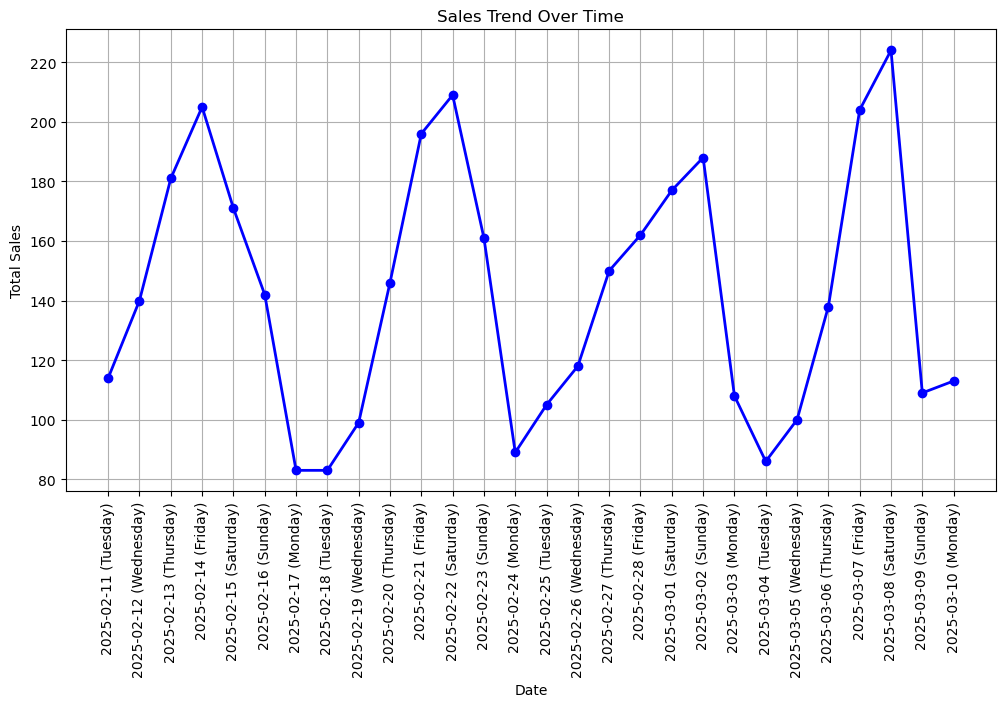

In [37]:
sales_trend = df_main.groupby('Date')['Sales'].sum()
plt.figure(figsize=(12, 6))
plt.plot(sales_trend.index, sales_trend.values, marker='o', linestyle='-', linewidth=2, color='blue')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Trend Over Time")
# Explicitly set all dates to show on the x-axis
plt.xticks(sales_trend.index, sales_trend.index.strftime('%Y-%m-%d (%A)'), rotation=90)

plt.grid(True)
plt.show()

* Identify that sales increase on friday;
* Spot low-demand days for adjustments.

## BEST-SELLING MEALS 

* Shows which meals sell the most;
* Helps in stock planning  - increase stock for top sellers;
* Useful if I like to deciding which meals to promote more.

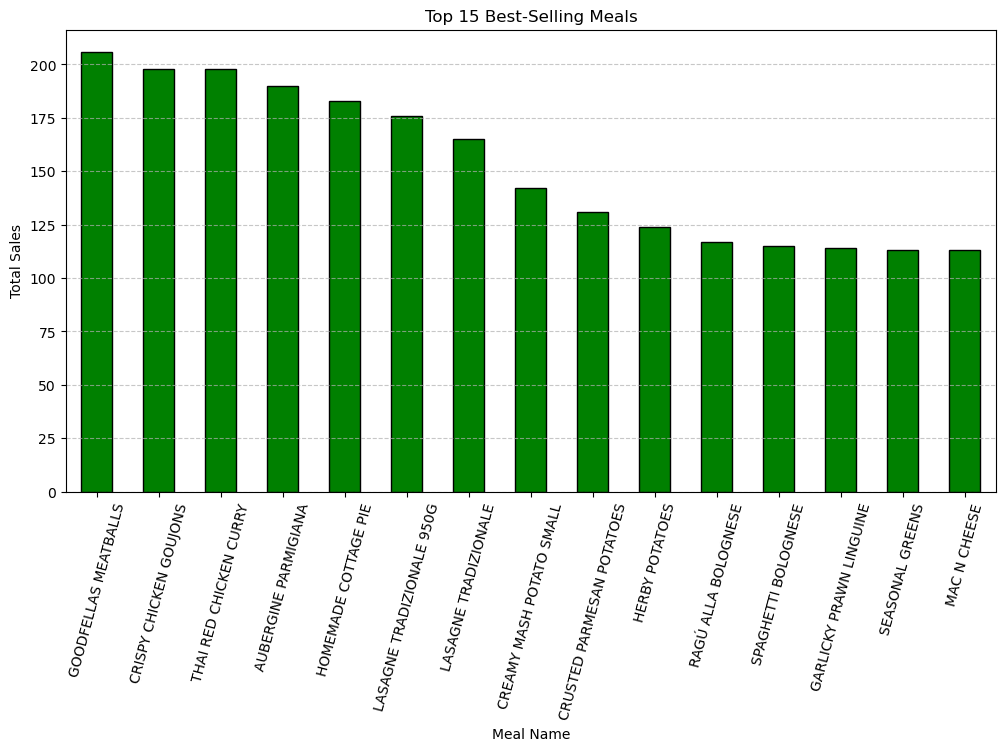

In [6]:
# best selling Meals
best_sellers = df.groupby('MealName')['Sales'].sum().sort_values(ascending=False).head(15)

# plot
plt.figure(figsize=(12, 6))
best_sellers.plot(kind='bar', color='green', edgecolor='black')
plt.xlabel("Meal Name")
plt.ylabel("Total Sales")
plt.title("Top 15 Best-Selling Meals")
plt.xticks(rotation=75)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


* Know which meals need more stock;
* Decide if any meal should have a higher price.

## STOCK NEED vs. SALES

* Comparing stock received vs. sales to know if stock is too high or too low.
* Helps decide which meals need increased or decreased stock.

<Figure size 1200x600 with 0 Axes>

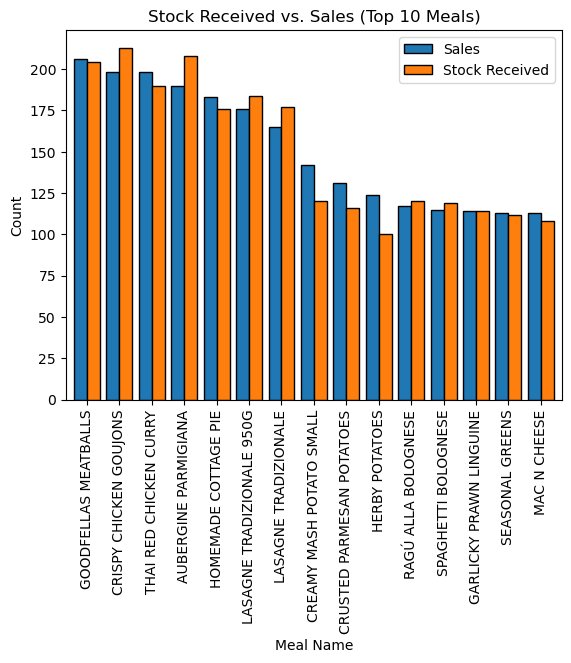

In [67]:
# columns
stock_vs_sales = df.groupby("MealName").agg({
    "Sales": "sum",
    "Received": "sum",
    "InitialStock": "max",  # starting stock level
    "FinalStock": "min"     # final stock level
}).sort_values(by="Sales", ascending=False)


plt.figure(figsize=(12, 6))
stock_vs_sales[["Sales", "Received"]].head(15).plot(kind="bar", width=0.8, edgecolor="black")
plt.xlabel("Meal Name")
plt.ylabel("Count")
plt.title("Stock Received vs. Sales (Top 10 Meals)")
plt.xticks(rotation=90)
plt.legend(["Sales", "Stock Received"])
plt.show()

* If sales are higher than stock, means a need to increase stock; 
* If stock is too high compared to sales, reduce orders.

## Meals That Ran Out on Friday and Saturday

* Highlights meals that sold out before the weekend (busiest days);


Meals Missing on Friday & Saturdays:
          Date                   MealName  Sales
138 2025-02-14       AUBERGINE PARMIGIANA     11
142 2025-02-14      CHICKEN BROCCOLI BAKE      6
143 2025-02-14       CHICKEN TIKKA MASALA      6
146 2025-02-14  CREAMY CHICKEN ITALIAN SP      3
147 2025-02-14     CREAMY CHICKEN MARSALA      3
..         ...                        ...    ...
947 2025-03-08                 CHAMP MASH      6
948 2025-03-08    CHORIZO SPICED POTATOES      2
950 2025-03-08   CREAMY MASH POTATO SMALL      8
951 2025-03-08  CRUSTED PARMESAN POTATOES      9
957 2025-03-08                 WHITE RICE      2

[204 rows x 3 columns]


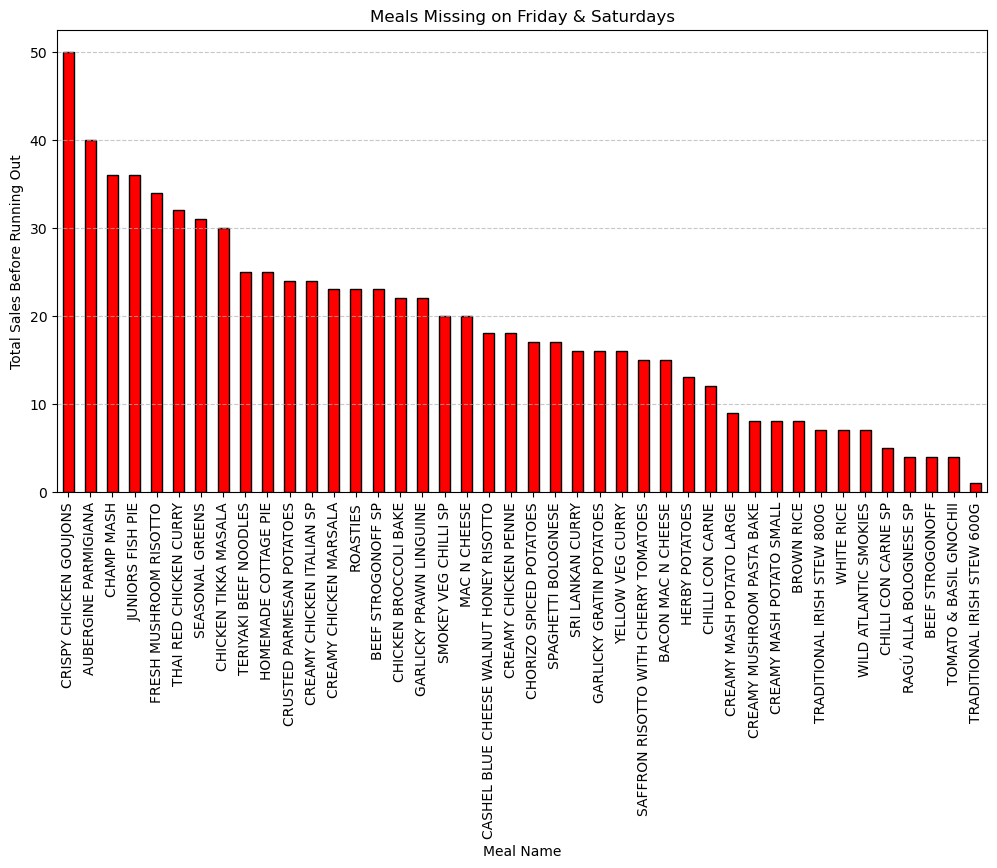

In [51]:
df['DayOfWeek'] = df['Date'].dt.day_name()

# Saturdays and Sundays
weekend_df = df[df['DayOfWeek'].isin(['Friday', 'Saturday'])]

missing_meals = weekend_df[
    (weekend_df['Sales'] > 0) & 
    (weekend_df['Received'] == 0)  # no new stock received
]

#display for missing meals
print("Meals Missing on Friday & Saturdays:")
print(missing_meals[['Date', 'MealName', 'Sales']])

# missing meals
missing_summary = missing_meals.groupby('MealName')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing_summary.plot(kind='bar', color='red', edgecolor='black')
plt.xlabel("Meal Name")
plt.ylabel("Total Sales Before Running Out")
plt.title("Meals Missing on Friday & Saturdays")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* Helps adjust stock levels to prevent shortages.

## Waste Analysis 
* meals that had the most waste;

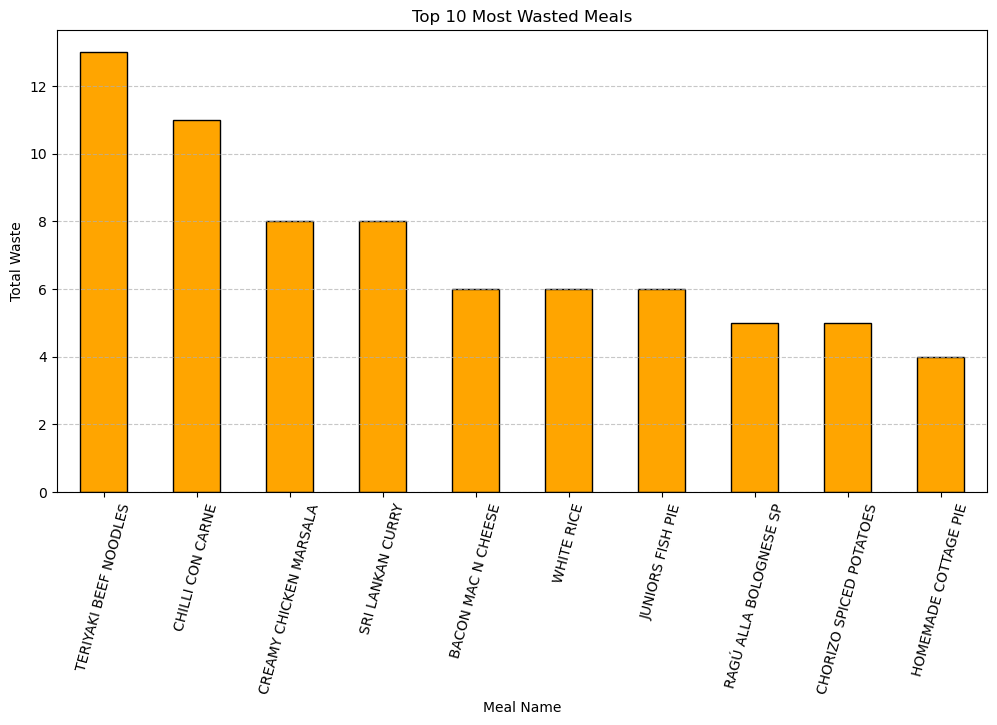

In [22]:

waste_analysis = df.groupby('MealName')['Waste'].sum().sort_values(ascending=False).head(10)

# plot
plt.figure(figsize=(12, 6))
waste_analysis.plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel("Meal Name")
plt.ylabel("Total Waste")
plt.title("Top 10 Most Wasted Meals")
plt.xticks(rotation=75)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
